<a href="https://colab.research.google.com/github/gracyntaxx/SmartSales/blob/main/Final_ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# loading cleaned dataset
df = pd.read_csv("/content/Cleaned_amazon_smartphones.csv")

# to drop duplicate items from dataset
df = df.drop_duplicates(subset=["product_name"])

# To remove invalid ratings
df =df[df["rating"] > 0]

print(df.shape)

# selecting input and output columns
X = df[["discounted_price", "actual_price", "discount_percentage", "rating"]]

y = df["rating_count"]

print("\nFeatures Selected")

(70, 17)

Features Selected


###Splitting dataset into training and testing

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 56
Testing Data: 14


###Linear Regression Model

In [19]:
print("\n----- Linear Regression -----")

lr = LinearRegression()

# training model
lr.fit(X_train, y_train)

print("Model Trained")

# predictions
lr_pred = lr.predict(X_test)

# checking accuracy
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("MAE:", lr_mae)
print("R2 Score:", lr_r2)


----- Linear Regression -----
Model Trained
MAE: 68323.454836807
R2 Score: -0.23797134759174976


###Random Forest Model

In [20]:
print("\n----- Random Forest -----")

rf = RandomForestRegressor(n_estimators=100, random_state=42)

# training model
rf.fit(X_train, y_train)

print("Random Forest Trained")

# predictions
rf_pred = rf.predict(X_test)

# accuracy
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("R2 Score:", rf_r2)


----- Random Forest -----
Random Forest Trained
MAE: 39187.23073809524
R2 Score: 0.2552645364225471


###Comparing Both Models

In [21]:
print("\n----- Model Comparison -----")

if rf_r2 > lr_r2:
    print("Random Forest gives better accuracy")
else:
    print("Linear Regression gives better accuracy")


----- Model Comparison -----
Random Forest gives better accuracy


###Feature Importance

In [22]:
importance = rf.feature_importances_

feature_data = pd.DataFrame({"Feature": X.columns,"Importance": importance})

feature_data = feature_data.sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_data)


Feature Importance:
               Feature  Importance
0     discounted_price    0.372949
1         actual_price    0.292090
3               rating    0.258869
2  discount_percentage    0.076093


###Actual vs Predicted Graph

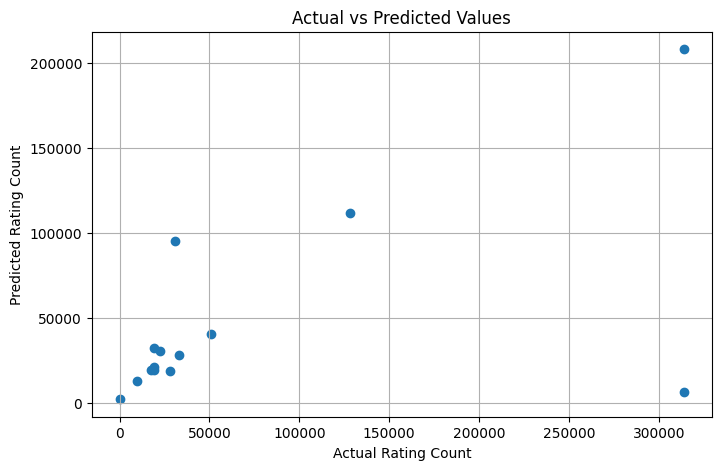

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Rating Count")
plt.ylabel("Predicted Rating Count")

plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

###K-Means Clustering

In [24]:
print("\n----- K-Means Clustering -----")

# selecting columns for clustering
cluster_data = df[["discounted_price", "rating"]]

# creating kmeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# fitting model
df["Cluster"] = kmeans.fit_predict(cluster_data)

print("Clusters Added Successfully")


----- K-Means Clustering -----
Clusters Added Successfully


###Naming Clusters

In [25]:
cluster_names = {0: "Budget", 1: "Mid-Range", 2: "Premium"}

df["Category"] = df["Cluster"].map(cluster_names)

print("\nPhone Categories:")
print(df[["product_name", "discounted_price", "rating", "Category"]].head())


Phone Categories:
                                        product_name  discounted_price  \
1  OnePlus Nord 2T 5G (Jade Fog, 8GB RAM, 128GB S...             28999   
2  OnePlus Nord 2T 5G (Gray Shadow, 8GB RAM, 128G...             28999   
3  Redmi A1 (Black, 2GB RAM, 32GB Storage) | Segm...              6499   
4  Redmi A1 (Light Green, 2GB RAM 32GB ROM) | Seg...              6499   
5  Nokia 105 Single SIM, Keypad Mobile Phone with...              1299   

   rating Category  
1     4.3  Premium  
2     4.3  Premium  
3     4.0   Budget  
4     4.0   Budget  
5     4.0   Budget  


###Cluster Graph

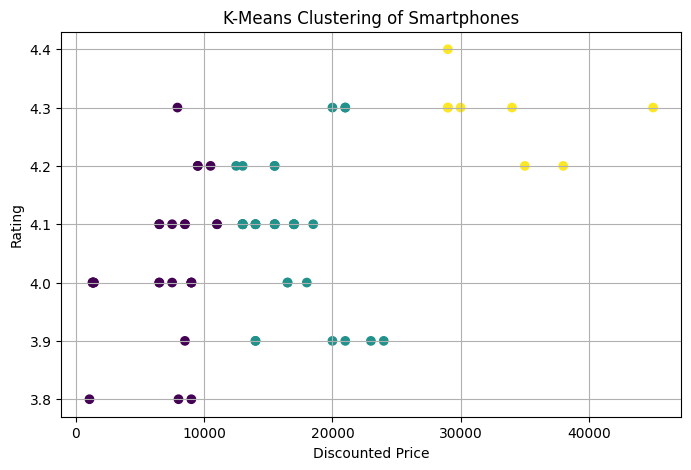

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df["discounted_price"],df["rating"],c=df["Cluster"])

plt.xlabel("Discounted Price")
plt.ylabel("Rating")

plt.title("K-Means Clustering of Smartphones")

plt.grid(True)

plt.show()

###Saving Prediction File

In [27]:
result = pd.DataFrame({"Actual": y_test, "Predicted": rf_pred})

result.to_csv("predictions.csv", index=False)

print("\nPrediction file saved")

# Saving Cluster Dataset
df.to_csv("clustered_phones.csv", index=False)

print("Clustered dataset saved")


Prediction file saved
Clustered dataset saved
